[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

# DCGAN — Generación de Rostros con CelebA

**Responsable de validación del dataset:** Claros Herbas André Shaiel (67617441)

---

Este cuadernillo adapta la implementación de *GANs* del cuadernillo de referencia (`01_gans.ipynb`) para implementar una **DCGAN** (*Deep Convolutional GAN*) sobre el dataset **CelebA**, un dataset multimodal de rostros de celebridades.

### ¿Por qué CelebA es un dataset multimodal?

CelebA es multimodal porque cada imagen está acompañada de:
- **Imagen RGB** (202,599 imágenes de 178×218 px, redimensionadas a 64×64)
- **40 atributos binarios** por imagen (género, edad, color de cabello, gafas, sonrisa, etc.)
- **5 puntos de referencia facial** (*landmarks*: ojos, nariz, boca)

La DCGAN aprende a **generar nuevas imágenes de rostros** que no existen en el dataset original.

### Comparación con el cuadernillo base

| Aspecto | GAN simple (base) | DCGAN CelebA (este notebook) |
|---|---|---|
| Dataset | Fashion MNIST 28×28 gris | CelebA 64×64 RGB |
| Generador | MLP (capas densas) | ConvTranspose2d (upsampling convolucional) |
| Discriminador | MLP | CNN con LeakyReLU |
| Canales | 1 (gris) | 3 (RGB) |
| Vector latente `z` | 30 / 100 | 100 |
| Normalización | `/255` → `[0,1]` | `*2 - 1` → `[-1,1]` + `tanh` |
| Pérdida | BCEWithLogitsLoss | BCELoss (con Sigmoid en D) |

---

## Paso 1 — Dataset CelebA

### Información del dataset

| Característica | Valor |
|---|---|
| Total de imágenes | 202,599 |
| Identidades únicas | 10,177 |
| Atributos binarios | 40 por imagen |
| Landmarks | 5 puntos faciales |
| Resolución original | 178×218 px |
| Resolución usada | **64×64 px** (mínimo requerido) |
| Canales | 3 (RGB) |
| Fuente | MMLAB, Chinese University of Hong Kong |

### Descarga del dataset

`torchvision.datasets.CelebA` descarga automáticamente el dataset desde Google Drive (requiere autenticación en Kaggle o descarga manual). Se proveen instrucciones para ambos métodos.
link: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset?resource=download

In [ ]:
# ── Instalaciones necesarias (ejecutar solo en Colab) ─────────────────────────
# !pip install torch torchvision tqdm matplotlib numpy pandas

# Para descargar CelebA desde Kaggle en Colab:
# !pip install kaggle
# !mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d jessicali9530/celeba-dataset --unzip -p ./data/celeba

print('✔ Instalaciones listas')

## Paso 2 — Importar librerías

| Librería | Uso |
|---|---|
| `torch / nn` | Definición y entrenamiento de Generator y Discriminator |
| `torchvision` | Carga de CelebA y transformaciones de imagen |
| `tqdm` | Barra de progreso por época y batch |
| `matplotlib` | Visualización de imágenes reales y generadas |
| `numpy / pandas` | Operaciones numéricas y curvas de pérdida |

In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

# ── Reproducibilidad ─────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✔ Dispositivo: {device}')
print(f'✔ PyTorch: {torch.__version__}')
print(f'✔ Torchvision: {torchvision.__version__}')

✔ Dispositivo: cuda
✔ PyTorch: 2.10.0+cu126
✔ Torchvision: 0.25.0+cu126


## Paso 3 — Hiperparámetros globales

| Hiperparámetro | Valor | Descripción |
|---|---|---|
| `IMG_SIZE` | 64 | Resolución de imagen (64×64 px) |
| `NC` | 3 | Canales de color (RGB) |
| `NZ` | 100 | Dimensión del vector latente `z` |
| `NGF` | 64 | Feature maps base del Generador |
| `NDF` | 64 | Feature maps base del Discriminador |
| `BATCH_SIZE` | 128 | Imágenes por mini-batch |
| `EPOCHS` | 30 | Épocas de entrenamiento |
| `LR` | 2e-4 | Learning rate (recomendado DCGAN paper) |
| `BETA1` | 0.5 | Beta1 para Adam (recomendado DCGAN paper) |

In [2]:
# ── Hiperparámetros ───────────────────────────────────────────────────────────
IMG_SIZE   = 64      # resolución mínima requerida (64×64)
NC         = 3       # canales RGB
NZ         = 100     # tamaño del vector latente z (igual que cuadernillo base)
NGF        = 64      # feature maps base del generador
NDF        = 64      # feature maps base del discriminador
BATCH_SIZE = 128
EPOCHS     = 30
LR         = 2e-4    # lr estándar del paper original DCGAN (Radford et al. 2015)
BETA1      = 0.5     # beta1 Adam recomendado para GANs

DATA_ROOT = './archive (4)'    # ajustar según ubicación del dataset

print('Hiperparámetros:')
print(f'  Imagen: {IMG_SIZE}×{IMG_SIZE}×{NC}  |  z: {NZ}  |  NGF/NDF: {NGF}/{NDF}')
print(f'  Batch: {BATCH_SIZE}  |  Épocas: {EPOCHS}  |  LR: {LR}  |  Beta1: {BETA1}')

Hiperparámetros:
  Imagen: 64×64×3  |  z: 100  |  NGF/NDF: 64/64
  Batch: 128  |  Épocas: 30  |  LR: 0.0002  |  Beta1: 0.5


## Paso 4 — Carga del dataset CelebA

### Transformaciones aplicadas

1. `CenterCrop(178)`: recorta el centro para eliminar bordes negros
2. `Resize(64)`: redimensiona a 64×64 px (resolución mínima requerida)
3. `ToTensor()`: convierte PIL Image → Tensor `[0, 1]`
4. `Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))`: normaliza a `[-1, 1]`

La normalización a `[-1, 1]` es necesaria porque el **generador usa `tanh`** como activación final (igual que en el cuadernillo base con la DCGAN para Fashion MNIST).

In [3]:
# ── Transformaciones de imagen ────────────────────────────────────────────────
# Normalización [-1, 1] necesaria para la activación tanh del generador.
# Equivalente a: img * 2 - 1  (como en el cuadernillo base con DCGAN Fashion MNIST)
transform = transforms.Compose([
    transforms.CenterCrop(178),          # recortar región central (elimina bordes)
    transforms.Resize(IMG_SIZE),         # 64×64 px — resolución mínima requerida
    transforms.ToTensor(),               # PIL → Tensor [0, 1]
    transforms.Normalize(               # [0,1] → [-1,1]  (igual que cuadernillo base)
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

# ── Cargar CelebA ─────────────────────────────────────────────────────────────
# Opción A: torchvision (descarga automática, puede requerir autenticación)
try:
    dataset = torchvision.datasets.CelebA(
        root=DATA_ROOT,
        split='train',
        transform=transform,
        download=True
    )
    print(f'✔ CelebA cargado con torchvision')

except Exception as e:
    # Opción B: ImageFolder si se descargó manualmente desde Kaggle
    # Estructura esperada: DATA_ROOT/img_align_celeba/*.jpg
    print(f'  Descarga automática falló: {e}')
    print(f'  Intentando carga manual desde {DATA_ROOT}/img_align_celeba ...')
    dataset = torchvision.datasets.ImageFolder(
        root=os.path.join(DATA_ROOT, 'img_align_celeba'),
        transform=transform
    )
    print(f'✔ CelebA cargado con ImageFolder')

dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True if device == 'cuda' else False
)

print(f'\n📊 Dataset: {len(dataset):,} imágenes')
print(f'   Batches por época: {len(dataloader):,}')
print(f'   Shape de una imagen: {dataset[0][0].shape}  →  (C, H, W)')
print(f'   Rango de valores: [{dataset[0][0].min():.1f}, {dataset[0][0].max():.1f}]  (normalizado [-1,1])')

  Descarga automática falló: To download files from GDrive, 'gdown' is required. You can install it with 'pip install gdown'.
  Intentando carga manual desde ./archive (4)/img_align_celeba ...
✔ CelebA cargado con ImageFolder

📊 Dataset: 202,599 imágenes
   Batches por época: 1,583
   Shape de una imagen: torch.Size([3, 64, 64])  →  (C, H, W)
   Rango de valores: [-1.0, 1.0]  (normalizado [-1,1])


## Paso 5 — Visualización de imágenes reales

Antes de entrenar, visualizamos muestras del dataset para confirmar que la carga y las transformaciones funcionan correctamente.

**Nota:** Para visualizar correctamente las imágenes normalizadas a `[-1, 1]` aplicamos la transformación inversa: `img * 0.5 + 0.5` → `[0, 1]`.

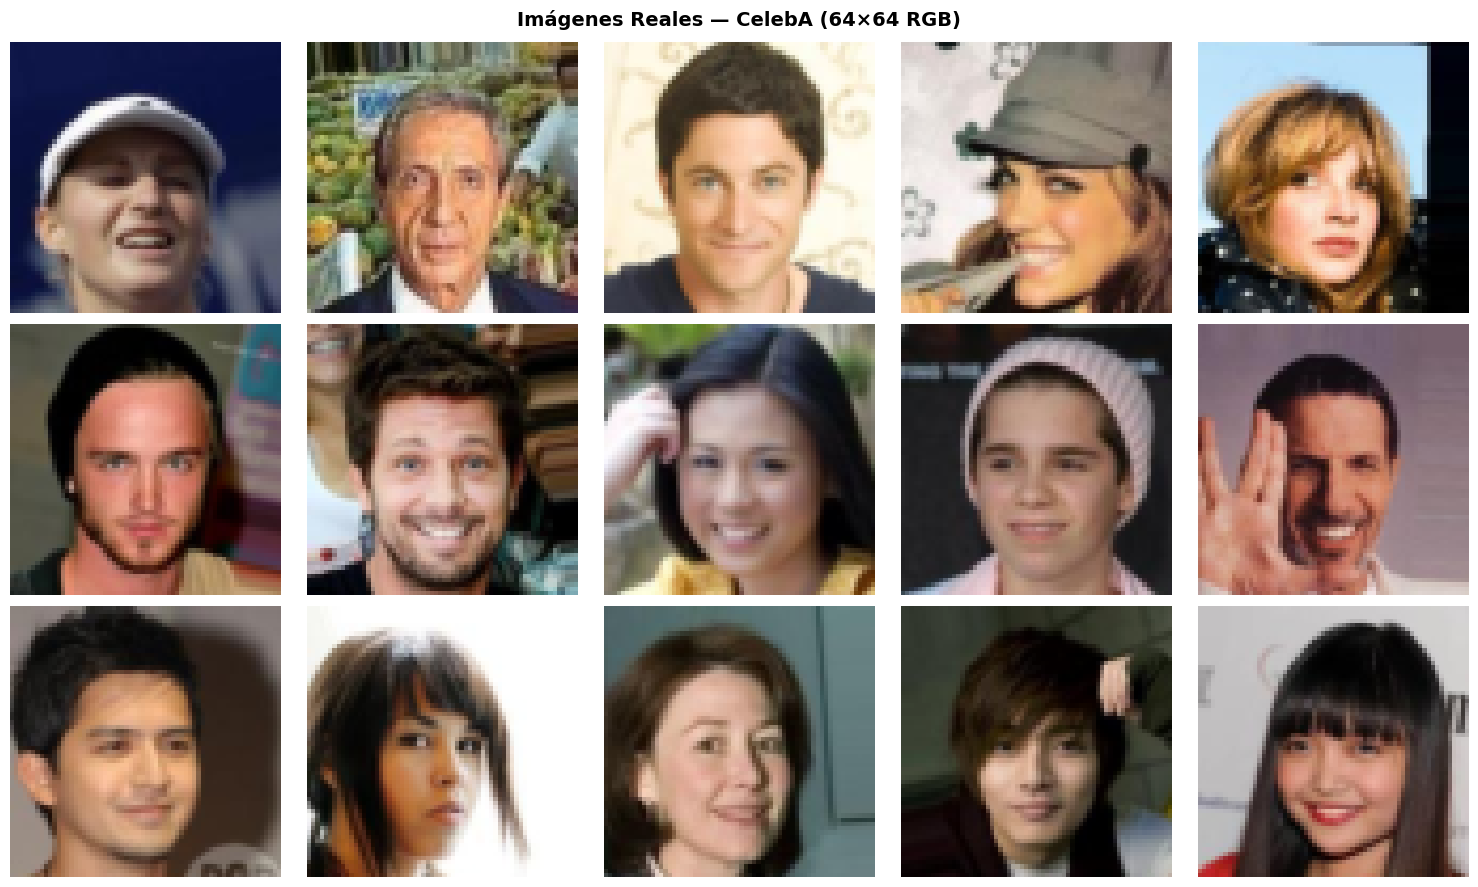

✔ Imágenes reales — shape: torch.Size([128, 3, 64, 64])  rango: [-1.00, 1.00]


In [4]:
# ── Visualizar imágenes reales del dataset ────────────────────────────────────
import random

real_batch = next(iter(dataloader))
real_imgs  = real_batch[0]  # (batch, C, H, W)

r, c = 3, 5   # mismo grid que cuadernillo base
plt.figure(figsize=(c*3, r*3))
plt.suptitle('Imágenes Reales — CelebA (64×64 RGB)', fontsize=14, fontweight='bold')

for row in range(r):
    for col in range(c):
        idx = c * row + col
        plt.subplot(r, c, idx + 1)
        # Desnormalizar: [-1,1] → [0,1]
        img = real_imgs[idx].permute(1, 2, 0).cpu().numpy()
        img = img * 0.5 + 0.5          # inversa de Normalize((0.5,...),(0.5,...))
        img = np.clip(img, 0, 1)
        plt.imshow(img)
        plt.axis('off')

plt.tight_layout()
plt.savefig('celeba_real_samples.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'✔ Imágenes reales — shape: {real_imgs.shape}  rango: [{real_imgs.min():.2f}, {real_imgs.max():.2f}]')

## Paso 6 — Arquitectura DCGAN

### Correcciones aplicadas sobre la versión anterior

| Problema | ❌ Versión anterior | ✅ Versión corregida |
|---|---|---|
| Generador híbrido | `nn.Linear` + reshape | **ConvTranspose2d desde `(NZ,1,1)`** |
| Entrada del generador | `(batch, NZ)` directo | **`(batch, NZ, 1, 1)` como tensor 4D** |
| Activación final D | `Sigmoid` | **Sin Sigmoid (BCEWithLogitsLoss)** |
| Función de pérdida | `BCELoss` | **`BCEWithLogitsLoss`** (más estable) |
| `.train()/.eval()` en fit | mal colocados | **G y D en `.train()` durante su fase** |
| Interpolación latente | lineal | **Esférica (slerp)** |

### Arquitectura del Generador (corregida)

```
z (NZ=100, 1, 1)
   → ConvT (NZ    → NGF*8, 4×4)   + BN + ReLU
   → ConvT (NGF*8 → NGF*4, 8×8)   + BN + ReLU
   → ConvT (NGF*4 → NGF*2, 16×16) + BN + ReLU
   → ConvT (NGF*2 → NGF,   32×32) + BN + ReLU
   → ConvT (NGF   → NC=3,  64×64) + Tanh
```

### Arquitectura del Discriminador

```
img (3, 64, 64)
   → Conv (NC=3  → NDF,   32×32) + LeakyReLU(0.2)     — sin BN
   → Conv (NDF   → NDF*2, 16×16) + BN + LeakyReLU(0.2)
   → Conv (NDF*2 → NDF*4, 8×8)   + BN + LeakyReLU(0.2)
   → Conv (NDF*4 → NDF*8, 4×4)   + BN + LeakyReLU(0.2)
   → Conv (NDF*8 → 1,     1×1)   — logit (sin Sigmoid)
```


In [6]:
# ── Inicialización de pesos (recomendada en el paper DCGAN) ───────────────────
# Los pesos Conv y ConvTranspose se inicializan con N(0, 0.02)
# Los pesos BatchNorm con N(1.0, 0.02) y bias=0
def weights_init(m):
    """
    Inicialización de pesos según Radford et al. (2015) DCGAN.
    Se aplica a todas las capas Conv, ConvTranspose y BatchNorm.
    """
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

print('✔ Función weights_init definida')

✔ Función weights_init definida


In [7]:
# ── Generador DCGAN 64×64 — pipeline 100% convolucional ─────────────────────
# CORRECCIÓN respecto a versión anterior:
#   ❌ Antes: nn.Linear(nz, ngf*8*4*4) + reshape  → introduce artefactos
#   ✅ Ahora: ConvTranspose2d desde (nz,1,1) → pipeline convolucional puro
#             z tiene shape (batch, NZ, 1, 1) — estándar del paper DCGAN

class Generator(nn.Module):
    """
    Generador DCGAN 100% convolucional para imágenes RGB 64×64.

    Entrada:  z  (batch, NZ=100, 1, 1)  — vector latente como tensor 4D
    Salida:   img (batch, NC=3,  64, 64) — imagen RGB normalizada en [-1,1]

    Pipeline de upsampling (ConvTranspose2d con stride=2):
        z  (NZ,    1,  1)
        →  (NGF*8, 4,  4)   + BN + ReLU
        →  (NGF*4, 8,  8)   + BN + ReLU
        →  (NGF*2, 16, 16)  + BN + ReLU
        →  (NGF,   32, 32)  + BN + ReLU
        →  (NC=3,  64, 64)  + Tanh  ← salida en [-1,1]

    Hiperparámetros:
        nz  = 100  — dimensión del vector latente
        ngf = 64   — feature maps base
        nc  = 3    — canales de salida (RGB)

    Diferencias con versión anterior (corregidas):
        ✅ z como (batch, NZ, 1, 1)     — elimina artefactos del Linear
        ✅ 5 ConvTranspose2d             — 1→4→8→16→32→64
        ✅ Sin nn.Linear ni reshape      — pipeline convolucional puro
        ✅ input_size = NZ               — compatible con inferencia
    """
    def __init__(self, nz=NZ, ngf=NGF, nc=NC):
        super().__init__()
        self.input_size = nz  # para compatibilidad en inferencia

        self.main = nn.Sequential(
            # (nz, 1, 1) → (ngf*8, 4, 4)
            nn.ConvTranspose2d(nz, ngf * 8, 4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(inplace=True),
            # (ngf*8, 4, 4) → (ngf*4, 8, 8)
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(inplace=True),
            # (ngf*4, 8, 8) → (ngf*2, 16, 16)
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(inplace=True),
            # (ngf*2, 16, 16) → (ngf, 32, 32)
            nn.ConvTranspose2d(ngf * 2, ngf, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(inplace=True),
            # (ngf, 32, 32) → (nc=3, 64, 64)  — capa final
            nn.ConvTranspose2d(ngf, nc, 4, stride=2, padding=1, bias=False),
            nn.Tanh()  # salida en [-1, 1]
        )

    def forward(self, z):
        # z puede venir como (batch, NZ) o (batch, NZ, 1, 1)
        # Normalizamos a 4D para el pipeline convolucional
        if z.dim() == 2:
            z = z.view(z.size(0), -1, 1, 1)  # (batch, NZ, 1, 1)
        return self.main(z)  # (batch, NC, 64, 64)


# ── Instanciar y verificar ────────────────────────────────────────────────────
generator = Generator().to(device)
generator.apply(weights_init)

# Test: z como (batch, NZ) — el forward lo convierte a 4D automáticamente
test_noise  = torch.randn(64, NZ, device=device)
test_output = generator(test_noise)

n_params_g = sum(p.numel() for p in generator.parameters())
print(f'✔ Generator — input: (batch, {NZ})  →  output: {test_output.shape}')
print(f'   Parámetros: {n_params_g:,}')
print(f'   Rango salida: [{test_output.min():.3f}, {test_output.max():.3f}]  (tanh → [-1,1])')
print(f'\n{generator}')


✔ Generator — input: (batch, 100)  →  output: torch.Size([64, 3, 64, 64])
   Parámetros: 3,576,704
   Rango salida: [-0.843, 0.814]  (tanh → [-1,1])

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [8]:
# ── Discriminador DCGAN 64×64 ─────────────────────────────────────────────────
# CORRECCIÓN: usar BCEWithLogitsLoss + sin Sigmoid en D
#   ❌ Antes: Sigmoid en D + BCELoss        → inestabilidad numérica
#   ✅ Ahora: sin Sigmoid + BCEWithLogitsLoss → más estable (log-sum-exp trick)

class Discriminator(nn.Module):
    """
    Discriminador DCGAN para imágenes RGB 64×64.

    Entrada:  img (batch, NC=3,  64, 64)
    Salida:   logit (batch, 1)  — SIN Sigmoid (aplicada por BCEWithLogitsLoss)

    Pipeline de downsampling (Conv2d con stride=2):
        (NC=3,  64, 64)
        → (NDF,   32, 32)  + LeakyReLU(0.2)       — sin BN en primera capa
        → (NDF*2, 16, 16)  + BN + LeakyReLU(0.2)
        → (NDF*4, 8,  8)   + BN + LeakyReLU(0.2)
        → (NDF*8, 4,  4)   + BN + LeakyReLU(0.2)
        → (1,     1,  1)   — logit de clasificación binaria

    Hiperparámetros:
        nc  = 3   — canales de entrada (RGB)
        ndf = 64  — feature maps base

    Diferencias con versión anterior (corregidas):
        ✅ Sin Sigmoid final         — BCEWithLogitsLoss lo incluye internamente
        ✅ LeakyReLU(0.2)            — estándar DCGAN para discriminadores
        ✅ Sin BN en primera capa    — recomendación paper DCGAN
    """
    def __init__(self, nc=NC, ndf=NDF):
        super().__init__()
        self.main = nn.Sequential(
            # (nc=3, 64, 64) → (ndf, 32, 32)  — SIN BatchNorm primera capa
            nn.Conv2d(nc, ndf, 4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf, 32, 32) → (ndf*2, 16, 16)
            nn.Conv2d(ndf, ndf * 2, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*2, 16, 16) → (ndf*4, 8, 8)
            nn.Conv2d(ndf * 2, ndf * 4, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*4, 8, 8) → (ndf*8, 4, 4)
            nn.Conv2d(ndf * 4, ndf * 8, 4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # (ndf*8, 4, 4) → (1, 1, 1) — logit final SIN Sigmoid
            nn.Conv2d(ndf * 8, 1, 4, stride=1, padding=0, bias=False)
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)  # (batch, 1) — logit crudo


# ── Instanciar y verificar ────────────────────────────────────────────────────
discriminator = Discriminator().to(device)
discriminator.apply(weights_init)

test_img   = torch.randn(64, NC, IMG_SIZE, IMG_SIZE, device=device)
test_d_out = discriminator(test_img)

n_params_d = sum(p.numel() for p in discriminator.parameters())
print(f'✔ Discriminator — input: (batch, {NC}, {IMG_SIZE}, {IMG_SIZE})  →  output: {test_d_out.shape}')
print(f'   Parámetros: {n_params_d:,}')
print(f'   Salida: logit crudo (sin Sigmoid) — se usa BCEWithLogitsLoss')
print(f'\n{discriminator}')
print(f'\n  Total parámetros GAN: {n_params_g + n_params_d:,}')


✔ Discriminator — input: (batch, 3, 64, 64)  →  output: torch.Size([64, 1])
   Parámetros: 2,765,568
   Salida: logit crudo (sin Sigmoid) — se usa BCEWithLogitsLoss

Discriminator(
  (main): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyR

## Paso 7 — Entrenamiento DCGAN

### Algoritmo de entrenamiento (igual que cuadernillo base)

El bucle de entrenamiento alterna entre dos fases **por cada batch**:

**Fase 1 — Entrenar el Discriminador:**
1. Generar batch de imágenes falsas con `G(z)`
2. Concatenar imágenes reales (`label=1`) y falsas (`label=0`)
3. Calcular `d_loss = BCE(D(real), 1) + BCE(D(fake), 0)`
4. Backprop y actualizar D

**Fase 2 — Entrenar el Generador:**
1. Generar nuevo batch de imágenes falsas
2. Calcular `g_loss = BCE(D(G(z)), 1)` ← engañar al discriminador
3. Backprop y actualizar G (D congelado)

### Función de pérdida

Se usa `BCELoss` (Binary Cross Entropy) porque el Discriminador ya incluye `Sigmoid` en la capa final (igual que la DCGAN del cuadernillo base para Fashion MNIST).

### Optimizador

`Adam(lr=2e-4, betas=(0.5, 0.999))` — parámetros recomendados en el paper original DCGAN (Radford et al. 2015).

In [9]:
# ── Ruido fijo para monitorear el progreso visual del generador ─────────────
# Shape (64, NZ) — el forward del Generator lo convierte a (64, NZ, 1, 1)
fixed_noise = torch.randn(64, NZ, device=device)

# ── Función fit — DCGAN corregida ────────────────────────────────────────────
# Correcciones respecto a versión anterior:
#   ✅ BCEWithLogitsLoss en lugar de BCELoss  — más estable numéricamente
#   ✅ g/d siempre en .train() durante su fase — BatchNorm funciona correctamente
#   ✅ Solo .detach() en fase D para fake_imgs — evitar doble backprop
#   ✅ Nueva generación de ruido para fase G   — independencia entre fases
#   ✅ Etiquetas como tensores 1D (b_size,)    — compatible con BCEWithLogitsLoss

def fit(g, d, dataloader, epochs=EPOCHS):
    """
    Entrena la DCGAN con el algoritmo estándar del paper (Goodfellow 2014).

    Algoritmo por batch:
    ──────────────────────────────────────────────────────────────────
    Fase D (entrenar discriminador, G congelado):
      1. d_loss_real = BCEWithLogits(D(x_real), 1)
      2. z  ~ N(0,I),  x_fake = G(z)
      3. d_loss_fake = BCEWithLogits(D(x_fake.detach()), 0)
      4. d_loss = d_loss_real + d_loss_fake
      5. d_loss.backward()  →  actualizar D

    Fase G (entrenar generador, D congelado):
      6. z  ~ N(0,I),  x_fake = G(z)   ← nuevo ruido, sin .detach()
      7. g_loss = BCEWithLogits(D(x_fake), 1)  ← G quiere engañar a D
      8. g_loss.backward()  →  actualizar G
    ──────────────────────────────────────────────────────────────────

    Parámetros:
    -----------
    g          : Generator
    d          : Discriminator
    dataloader : DataLoader de CelebA
    epochs     : int

    Retorna:
    --------
    hist     : dict  {'g_loss': [...], 'd_loss': [...]}  — pérdidas por época
    img_list : list  — grillas de imágenes generadas (una por época)
    """
    g.to(device)
    d.to(device)

    # Optimizadores — Adam con beta1=0.5 según paper DCGAN (Radford et al. 2015)
    g_optimizer = torch.optim.Adam(g.parameters(), lr=LR, betas=(BETA1, 0.999))
    d_optimizer = torch.optim.Adam(d.parameters(), lr=LR, betas=(BETA1, 0.999))

    # BCEWithLogitsLoss = Sigmoid + BCELoss en una sola operación
    # Más estable numéricamente que BCELoss(Sigmoid(x)) por separado
    crit = nn.BCEWithLogitsLoss()

    # Etiquetas — 1D para BCEWithLogitsLoss
    REAL_LABEL = 1.0   # D debe clasificar reales como 1
    FAKE_LABEL = 0.0   # D debe clasificar falsas como 0

    hist     = {'g_loss': [], 'd_loss': []}
    img_list = []

    print(f'Iniciando entrenamiento DCGAN')
    print(f'  Épocas: {epochs}  |  Batches/época: {len(dataloader)}')
    print(f'  Dispositivo: {device}')
    print('─' * 65)

    for epoch in range(1, epochs + 1):
        g_losses_epoch = []
        d_losses_epoch = []

        # Ambos en modo train al inicio de cada época
        g.train()
        d.train()

        bar = tqdm(dataloader, desc=f'Época {epoch:>3}/{epochs}', leave=False)

        for real_imgs, _ in bar:
            real_imgs = real_imgs.to(device)  # (batch, 3, 64, 64)
            b_size    = real_imgs.size(0)

            # ── FASE D: Entrenar Discriminador ───────────────────────────────
            # G permanece en .train() pero sus gradientes no se acumulan
            # porque usamos .detach() en fake_imgs
            d_optimizer.zero_grad()

            # D con imágenes reales — etiqueta = 1
            label_real  = torch.full((b_size,), REAL_LABEL,
                                     dtype=torch.float32, device=device)
            d_out_real  = d(real_imgs)
            d_loss_real = crit(d_out_real.squeeze(), label_real)

            # D con imágenes falsas — etiqueta = 0
            # .detach() evita que los gradientes fluyan hacia G en esta fase
            noise       = torch.randn(b_size, NZ, device=device)
            fake_imgs   = g(noise)                     # G genera imágenes
            label_fake  = torch.full((b_size,), FAKE_LABEL,
                                     dtype=torch.float32, device=device)
            d_out_fake  = d(fake_imgs.detach())        # ← .detach() correcto
            d_loss_fake = crit(d_out_fake.squeeze(), label_fake)

            d_loss = d_loss_real + d_loss_fake
            d_loss.backward()
            d_optimizer.step()

            # ── FASE G: Entrenar Generador ───────────────────────────────────
            # D permanece en .train() pero sus parámetros no se actualizan
            # porque usamos g_optimizer (no d_optimizer)
            g_optimizer.zero_grad()

            # Nuevo ruido — independiente del usado en fase D
            noise      = torch.randn(b_size, NZ, device=device)
            fake_imgs  = g(noise)             # SIN .detach() — queremos gradientes
            # G quiere que D clasifique sus imágenes como reales (label=1)
            label_g    = torch.full((b_size,), REAL_LABEL,
                                    dtype=torch.float32, device=device)
            d_out_g    = d(fake_imgs)
            g_loss     = crit(d_out_g.squeeze(), label_g)
            g_loss.backward()
            g_optimizer.step()

            g_losses_epoch.append(g_loss.item())
            d_losses_epoch.append(d_loss.item())

            bar.set_postfix({
                'g_loss': f'{np.mean(g_losses_epoch):.4f}',
                'd_loss': f'{np.mean(d_losses_epoch):.4f}'
            })

        avg_g = np.mean(g_losses_epoch)
        avg_d = np.mean(d_losses_epoch)
        hist['g_loss'].append(avg_g)
        hist['d_loss'].append(avg_d)

        # Guardar grilla de imágenes generadas con ruido fijo
        g.eval()
        with torch.no_grad():
            fake_fixed = g(fixed_noise).cpu()
        # normalize=True: ajusta al rango [0,1] sin necesidad de desnormalizar manual
        grid = vutils.make_grid(fake_fixed[:25], nrow=5, normalize=True, value_range=(-1, 1))
        img_list.append(grid)
        g.train()

        print(f'Época {epoch:>3}/{epochs}  |  g_loss: {avg_g:.5f}  d_loss: {avg_d:.5f}')

    print('─' * 65)
    print('✔ Entrenamiento finalizado')
    return hist, img_list


print('✔ fit() definido correctamente')
print('  BCEWithLogitsLoss: ✅  |  sin Sigmoid en D: ✅  |  .detach() solo en fase D: ✅')


✔ fit() definido correctamente
  BCEWithLogitsLoss: ✅  |  sin Sigmoid en D: ✅  |  .detach() solo en fase D: ✅


In [10]:
# ── Ejecutar entrenamiento ────────────────────────────────────────────────────
generator     = Generator().to(device)
discriminator = Discriminator().to(device)
generator.apply(weights_init)
discriminator.apply(weights_init)

# Verificación de shapes antes de entrenar
with torch.no_grad():
    z_test   = torch.randn(2, NZ, device=device)
    img_test = generator(z_test)
    d_test   = discriminator(img_test)
    print(f'✔ Verificación previa al entrenamiento:')
    print(f'  G input:  {z_test.shape}  →  G output: {img_test.shape}')
    print(f'  D input:  {img_test.shape}  →  D output: {d_test.shape}')
    print(f'  Rango G:  [{img_test.min():.3f}, {img_test.max():.3f}]')
    print()

hist, img_list = fit(generator, discriminator, dataloader, epochs=EPOCHS)


✔ Verificación previa al entrenamiento:
  G input:  torch.Size([2, 100])  →  G output: torch.Size([2, 3, 64, 64])
  D input:  torch.Size([2, 3, 64, 64])  →  D output: torch.Size([2, 1])
  Rango G:  [-0.724, 0.862]

Iniciando entrenamiento DCGAN
  Épocas: 30  |  Batches/época: 1583
  Dispositivo: cuda
─────────────────────────────────────────────────────────────────


Época   1/30  |  g_loss: 4.89391  d_loss: 0.67799


Época   2/30  |  g_loss: 3.39003  d_loss: 0.67179


Época   3/30  |  g_loss: 2.55568  d_loss: 0.74374


Época   4/30  |  g_loss: 2.45388  d_loss: 0.74404


...

Época  26/30  |  g_loss: 4.25183  d_loss: 0.34378


Época  27/30  |  g_loss: 4.44117  d_loss: 0.27625


Época  28/30  |  g_loss: 4.44266  d_loss: 0.30447


Época  29/30  |  g_loss: 4.18887  d_loss: 0.37238


Época  30/30  |  g_loss: 4.39510  d_loss: 0.30117
─────────────────────────────────────────────────────────────────
✔ Entrenamiento finalizado


## Paso 8 — Curvas de pérdida

El comportamiento esperado en una GAN bien entrenada:

- `g_loss`: comienza alta, disminuye progresivamente conforme el generador aprende a engañar al discriminador
- `d_loss`: sube inicialmente (el generador lo engaña cada vez más), se estabiliza alrededor de `ln(2) ≈ 0.693` en el equilibrio de Nash

> Como se explica en el cuadernillo base: que la `d_loss` suba **no significa que el discriminador sea malo** — significa que el generador ha mejorado tanto que el discriminador ya no puede distinguir fácilmente.

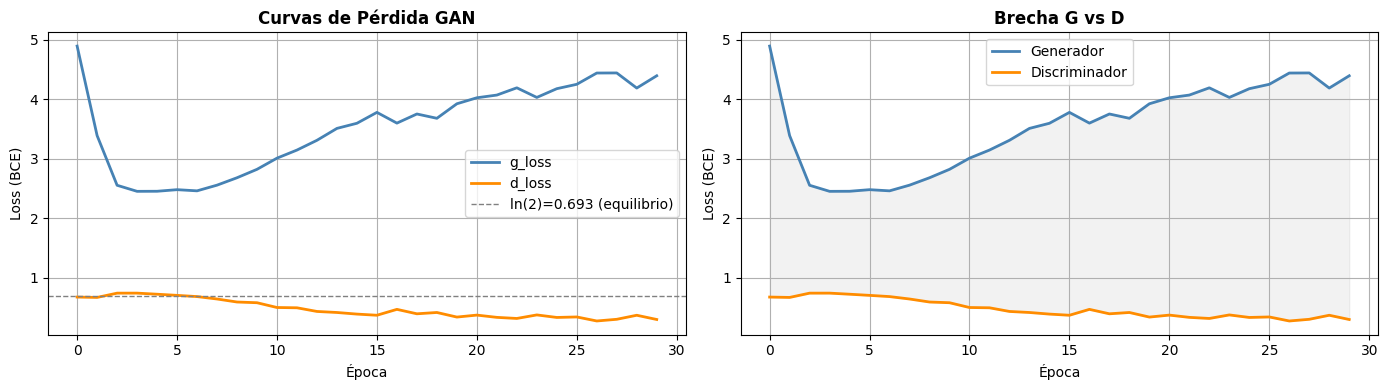

g_loss final: 4.39510
d_loss final: 0.30117
(equilibrio ideal d_loss ≈ 0.693)


In [11]:
# ── Curvas de pérdida — igual que cuadernillo base ────────────────────────────
df = pd.DataFrame(hist)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfica combinada (igual que cuadernillo base)
axes[0].plot(df['g_loss'], label='g_loss', color='steelblue', linewidth=2)
axes[0].plot(df['d_loss'], label='d_loss', color='darkorange', linewidth=2)
axes[0].axhline(y=0.693, color='gray', linestyle='--', linewidth=1,
                label='ln(2)=0.693 (equilibrio)')
axes[0].set_title('Curvas de Pérdida GAN', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (BCE)')
axes[0].legend()
axes[0].grid(True)

# Detalle por separado
axes[1].plot(df['g_loss'], label='Generador', color='steelblue', linewidth=2)
axes[1].plot(df['d_loss'], label='Discriminador', color='darkorange', linewidth=2)
axes[1].fill_between(range(len(df)), df['g_loss'], df['d_loss'], alpha=0.1, color='gray')
axes[1].set_title('Brecha G vs D', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss (BCE)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('dcgan_loss_curves.png', dpi=110, bbox_inches='tight')
plt.show()

print(f'g_loss final: {hist["g_loss"][-1]:.5f}')
print(f'd_loss final: {hist["d_loss"][-1]:.5f}')
print(f'(equilibrio ideal d_loss ≈ 0.693)')

## Paso 9 — Imágenes generadas

### Visualización final — igual que cuadernillo base

Usamos el mismo patrón `2×5 = 10 imágenes` del cuadernillo de referencia, y adicionalmente una grilla de 5×5 para mostrar más diversidad.

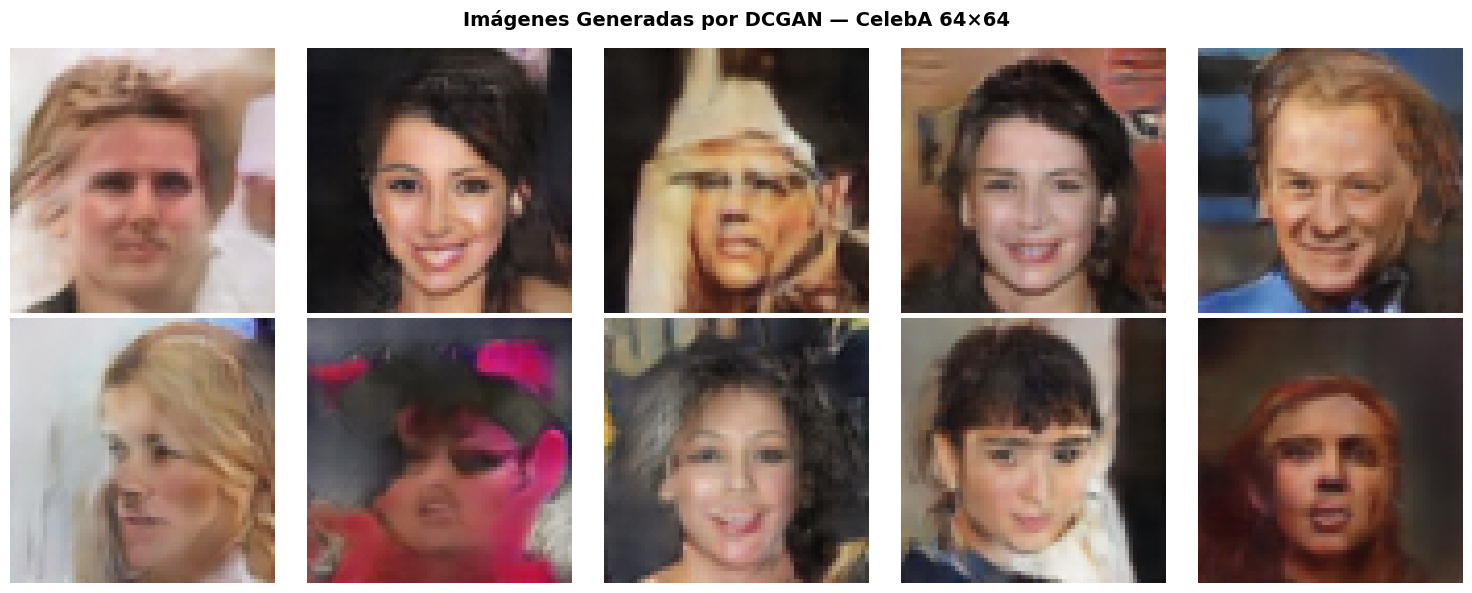

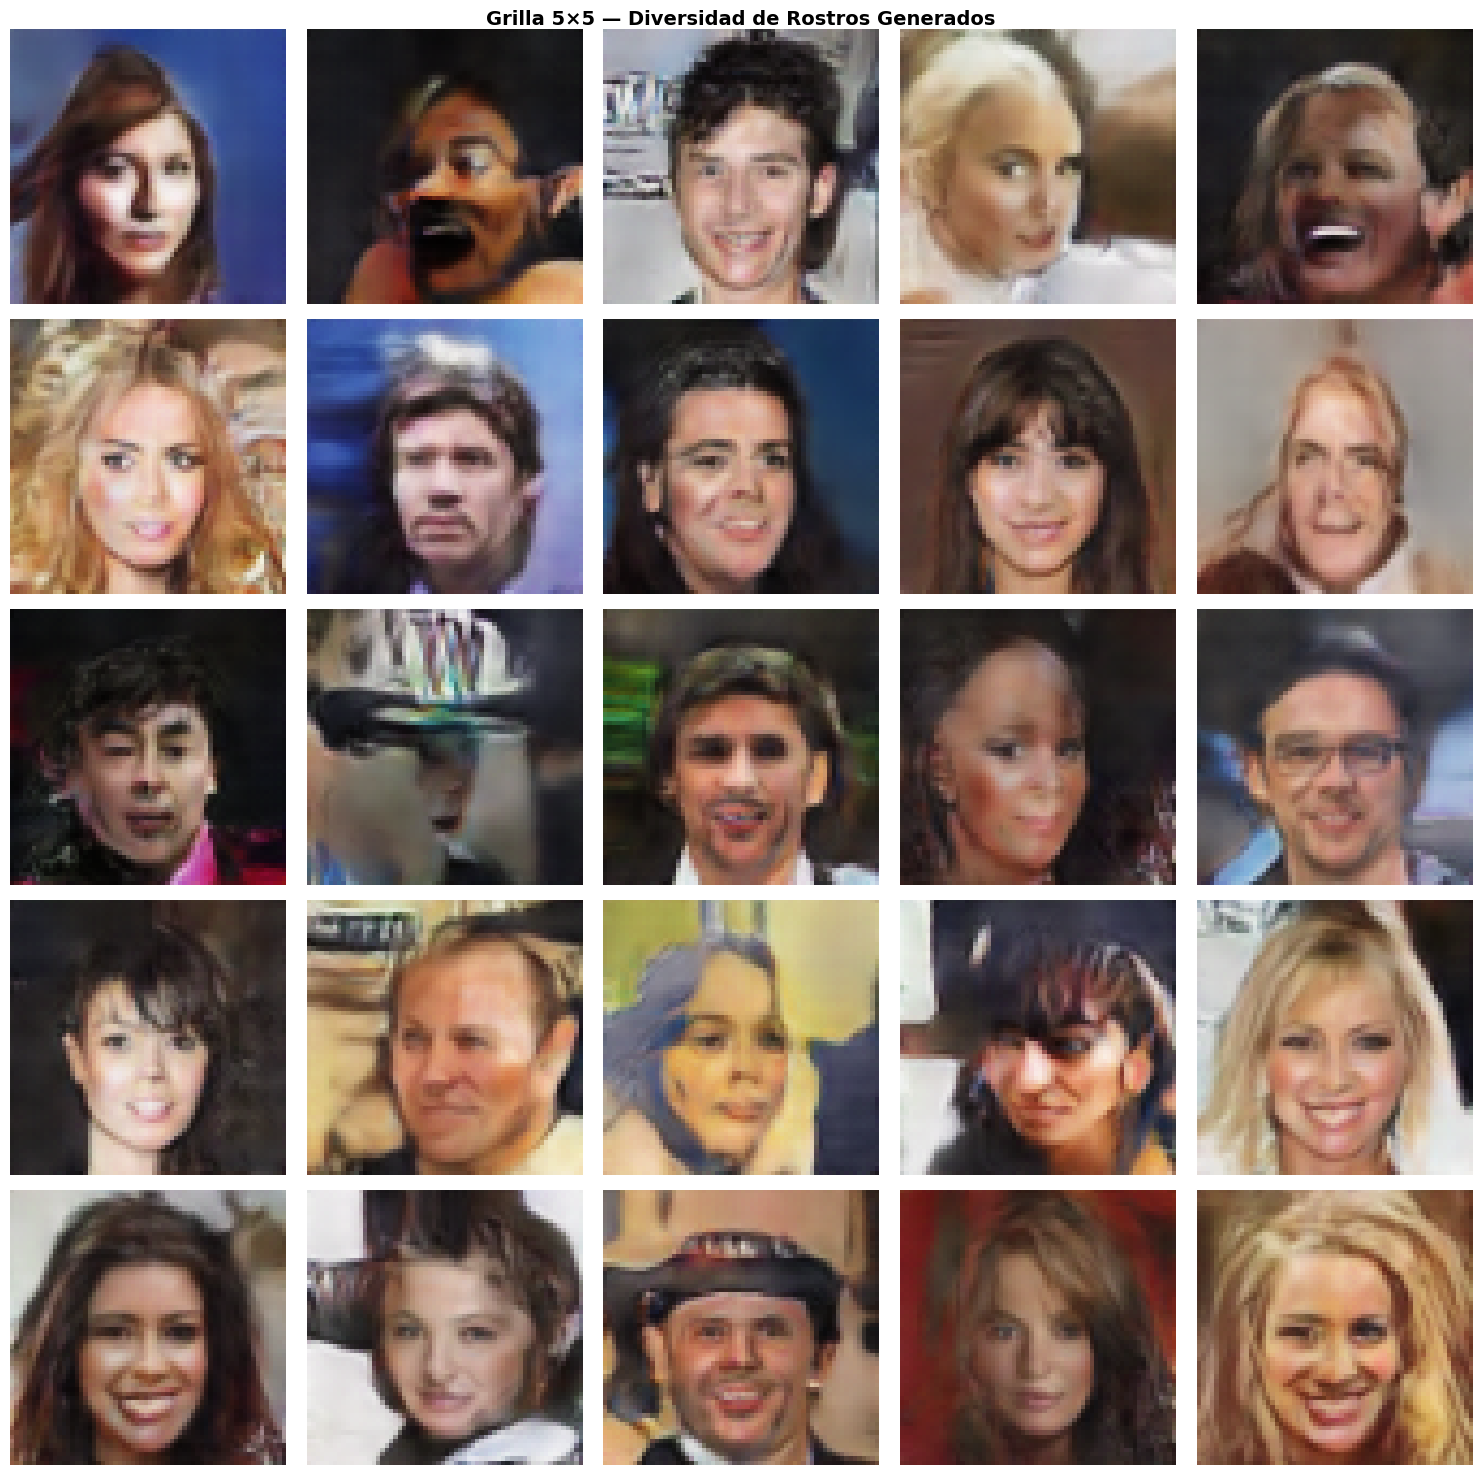

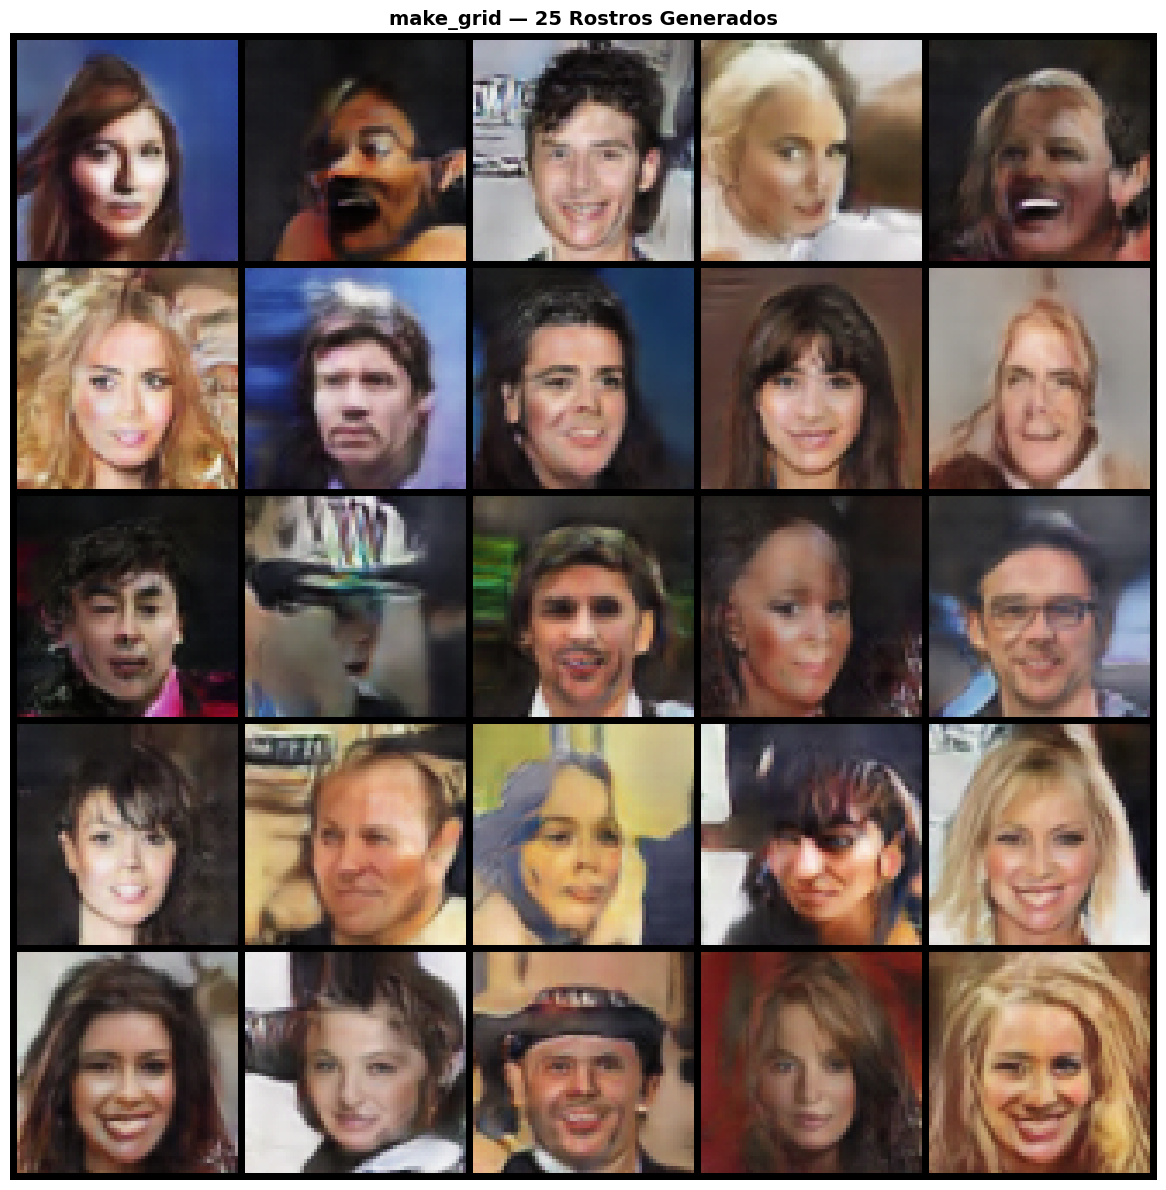

In [12]:
# ── Imágenes generadas — mismo patrón que cuadernillo base ───────────────────
generator.eval()
with torch.no_grad():
    noise = torch.randn(10, NZ, device=device)
    generated_images = generator(noise).cpu()

def show_generated(imgs, title, rows=2, cols=5, fname=None):
    """
    Muestra un grid de imágenes generadas desnormalizadas correctamente.
    Usa value_range=(-1,1) en make_grid para evitar artefactos de normalización.
    """
    grid = vutils.make_grid(imgs, nrow=cols, normalize=True, value_range=(-1, 1))
    grid_np = grid.permute(1, 2, 0).numpy()

    fig, axs = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    idx = 0
    for ax_row in axs:
        for ax in ax_row:
            img = imgs[idx].permute(1, 2, 0).numpy()
            img = (img * 0.5 + 0.5).clip(0, 1)  # [-1,1] → [0,1]
            ax.imshow(img)
            ax.axis('off')
            idx += 1
    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=110, bbox_inches='tight')
    plt.show()

# Grid 2×5 — idéntico al cuadernillo base
show_generated(generated_images[:10],
               'Imágenes Generadas por DCGAN — CelebA 64×64',
               rows=2, cols=5, fname='dcgan_generated_2x5.png')

# Grilla 5×5 — 25 imágenes para mayor diversidad
with torch.no_grad():
    noise_big = torch.randn(25, NZ, device=device)
    generated_big = generator(noise_big).cpu()

show_generated(generated_big,
               'Grilla 5×5 — Diversidad de Rostros Generados',
               rows=5, cols=5, fname='dcgan_generated_5x5.png')

# Grid unificado con make_grid
fig, ax = plt.subplots(figsize=(12, 12))
grid_viz = vutils.make_grid(generated_big, nrow=5, normalize=True, value_range=(-1, 1))
ax.imshow(grid_viz.permute(1, 2, 0).numpy())
ax.axis('off')
ax.set_title('make_grid — 25 Rostros Generados', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dcgan_make_grid.png', dpi=110, bbox_inches='tight')
plt.show()


## Paso 10 — Evolución del Generador a lo largo del entrenamiento

Visualizamos cómo mejoran las imágenes generadas a lo largo de las épocas usando el mismo ruido fijo (`fixed_noise`). Esto permite apreciar la evolución del generador desde ruido puro hasta rostros reconocibles.

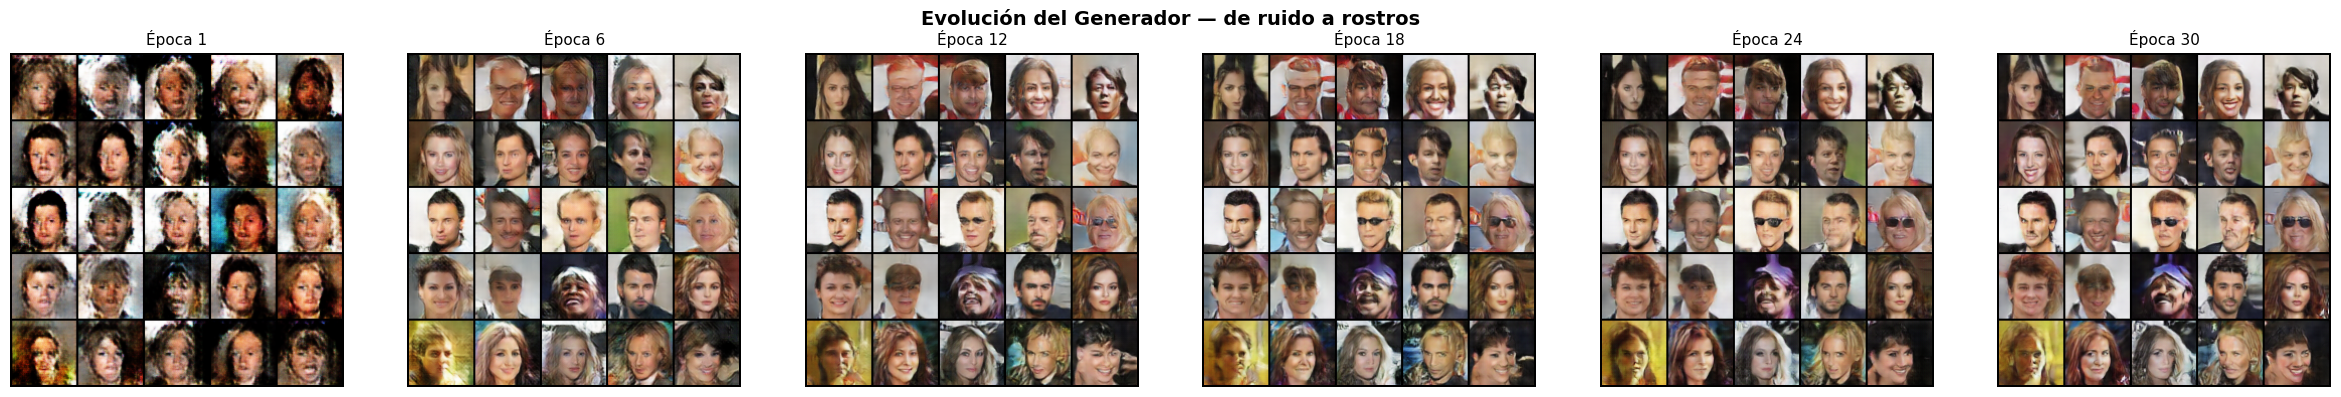

✔ Evolución guardada


In [13]:
# ── Evolución del generador por época ────────────────────────────────────────
n_epochs_show = min(EPOCHS, 6)
epoch_indices = np.linspace(0, len(img_list) - 1, n_epochs_show, dtype=int)

fig, axes = plt.subplots(1, n_epochs_show, figsize=(n_epochs_show * 4, 4))
fig.suptitle('Evolución del Generador — de ruido a rostros', fontsize=14, fontweight='bold')

if n_epochs_show == 1:
    axes = [axes]

for ax, ep_idx in zip(axes, epoch_indices):
    # img_list ya contiene grids con value_range=(-1,1) aplicado en fit()
    grid = img_list[ep_idx].permute(1, 2, 0).numpy()
    ax.imshow(grid)
    ax.set_title(f'Época {ep_idx + 1}', fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('dcgan_evolution.png', dpi=110, bbox_inches='tight')
plt.show()
print('✔ Evolución guardada')


## Paso 11 — Comparación: Real vs Generado

Mostramos imágenes reales del dataset junto a imágenes generadas para evaluar visualmente la calidad del generador.

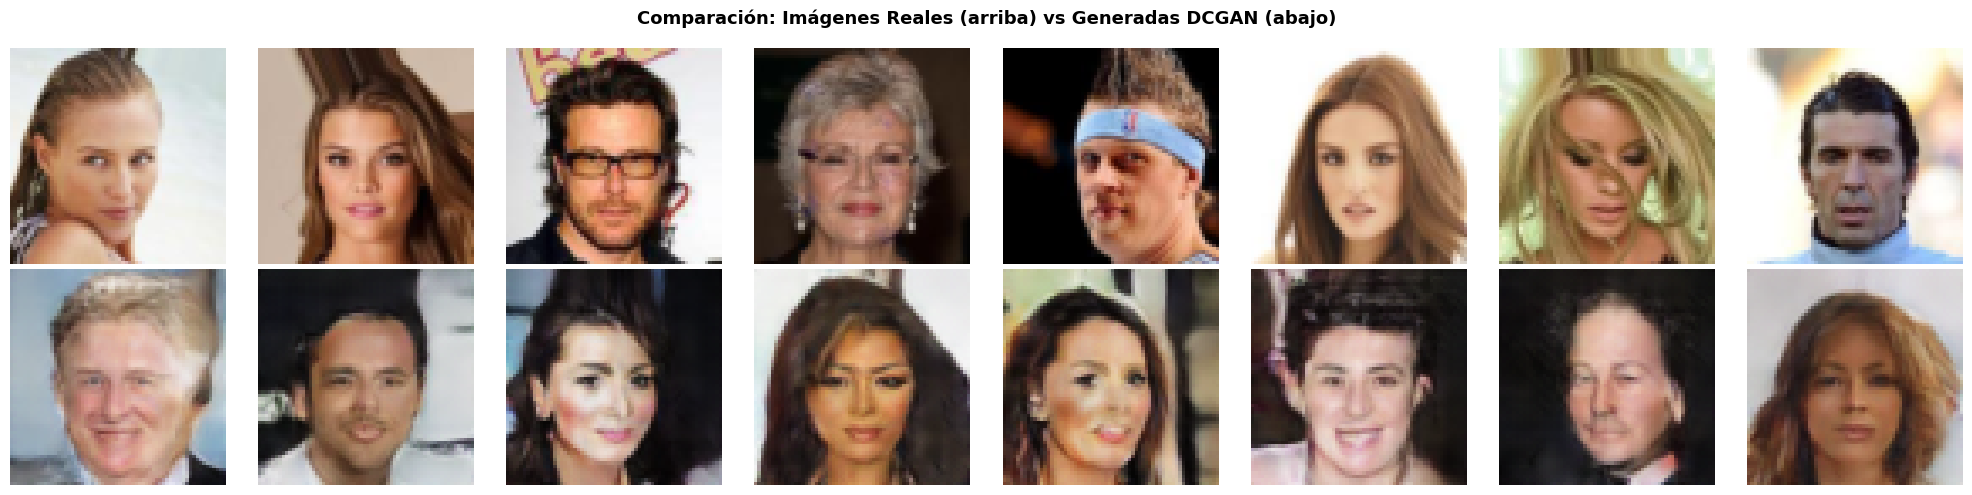

In [14]:
# ── Real vs Generado — comparación lado a lado ───────────────────────────────
generator.eval()
with torch.no_grad():
    noise_cmp   = torch.randn(8, NZ, device=device)
    fake_cmp    = generator(noise_cmp).cpu()

real_cmp = next(iter(dataloader))[0][:8].cpu()

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
fig.suptitle('Comparación: Imágenes Reales (arriba) vs Generadas DCGAN (abajo)',
             fontsize=13, fontweight='bold')

for col in range(8):
    # Fila 0: imágenes reales
    img_r = real_cmp[col].permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[0][col].imshow(np.clip(img_r, 0, 1))
    axes[0][col].axis('off')
    if col == 0:
        axes[0][col].set_ylabel('Real', fontsize=11, rotation=0,
                                 labelpad=40, fontweight='bold')

    # Fila 1: imágenes generadas
    img_f = fake_cmp[col].permute(1, 2, 0).numpy() * 0.5 + 0.5
    axes[1][col].imshow(np.clip(img_f, 0, 1))
    axes[1][col].axis('off')
    if col == 0:
        axes[1][col].set_ylabel('DCGAN', fontsize=11, rotation=0,
                                  labelpad=40, fontweight='bold')

plt.tight_layout()
plt.savefig('dcgan_real_vs_fake.png', dpi=110, bbox_inches='tight')
plt.show()

## Paso 12 — Interpolación en el espacio latente

Una propiedad notable de las GANs es que el espacio latente `z` es continuo y semánticamente significativo. Al **interpolar linealmente** entre dos vectores `z`, el generador produce una transición suave entre dos rostros distintos.

Esto no es posible con el MLP simple del cuadernillo base — es una ventaja específica de la DCGAN.

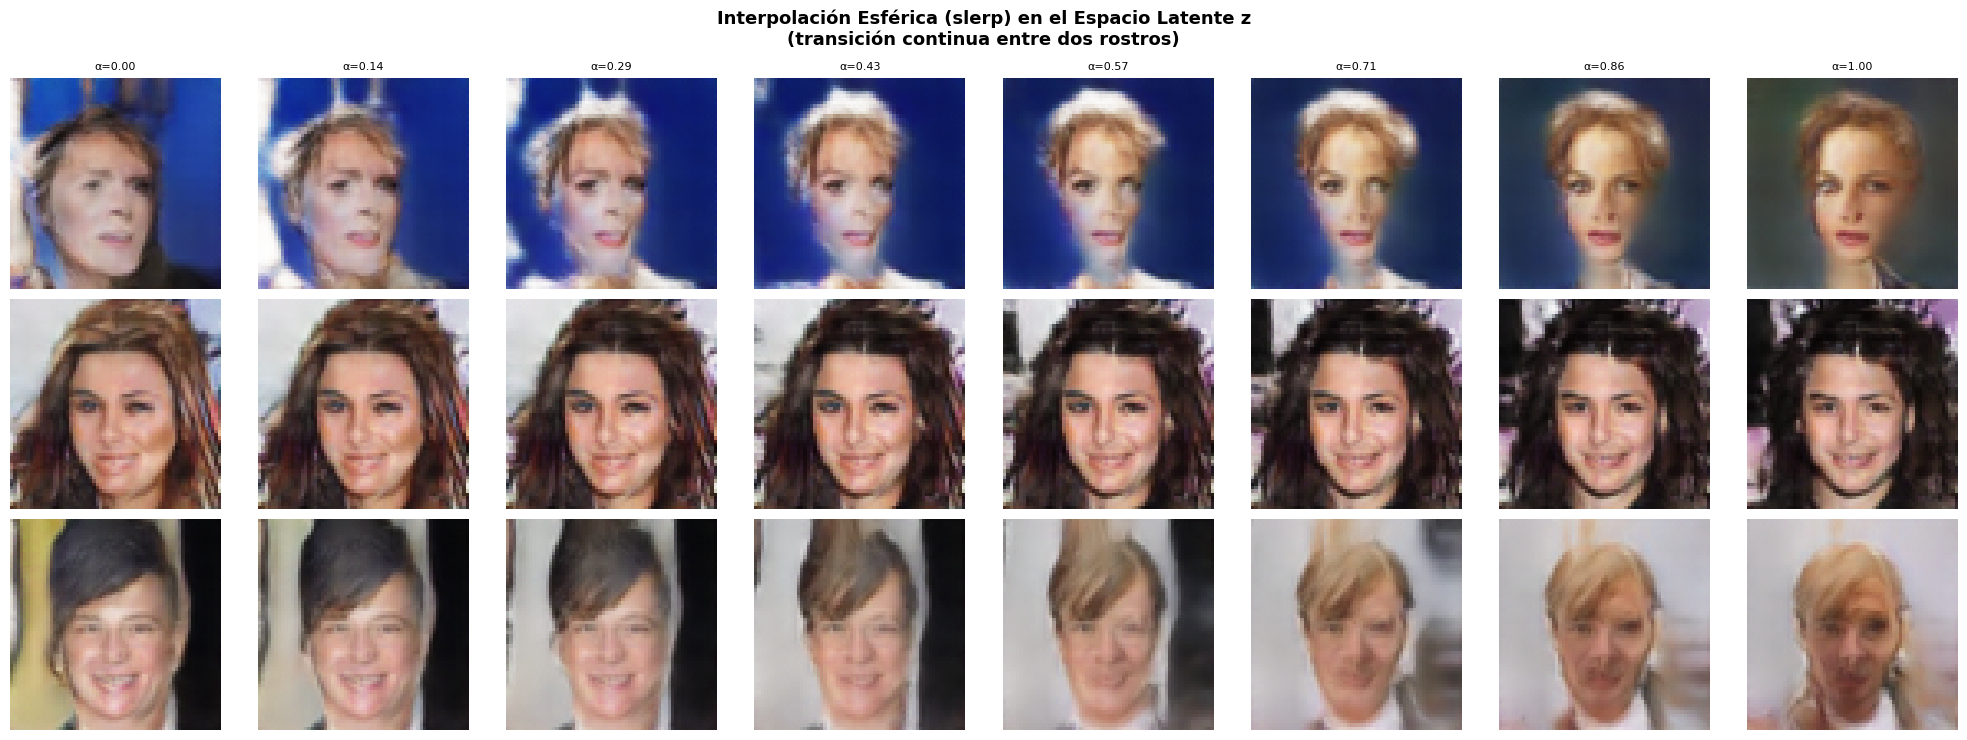

✔ Interpolación esférica guardada


In [15]:
# ── Interpolación esférica en el espacio latente (slerp) ────────────────────
# CORRECCIÓN: usar interpolación esférica (slerp) en lugar de lineal
# para moverse correctamente en una distribución gaussiana N(0,I)

def slerp(z1, z2, alpha):
    """
    Interpolación esférica (Spherical Linear intERPolation) entre z1 y z2.
    Más correcta que interpolación lineal para espacios latentes gaussianos:
    mantiene la norma constante y evita colapsar al centro de la distribución.

    alpha=0 → z1,  alpha=1 → z2
    """
    z1_n = z1 / z1.norm(dim=-1, keepdim=True)
    z2_n = z2 / z2.norm(dim=-1, keepdim=True)
    omega = torch.acos((z1_n * z2_n).sum(dim=-1, keepdim=True).clamp(-1, 1))
    sin_omega = torch.sin(omega)
    # Evitar división por cero cuando z1 ≈ z2
    out = torch.where(
        sin_omega.abs() < 1e-6,
        (1 - alpha) * z1 + alpha * z2,
        (torch.sin((1 - alpha) * omega) / sin_omega) * z1 +
        (torch.sin(alpha * omega)       / sin_omega) * z2
    )
    return out

generator.eval()
N_INTERP = 8
N_PAIRS  = 3

fig, axes = plt.subplots(N_PAIRS, N_INTERP, figsize=(N_INTERP * 2.5, N_PAIRS * 2.5))
fig.suptitle('Interpolación Esférica (slerp) en el Espacio Latente z\n'
             '(transición continua entre dos rostros)',
             fontsize=13, fontweight='bold')

with torch.no_grad():
    for row in range(N_PAIRS):
        z1 = torch.randn(1, NZ, device=device)
        z2 = torch.randn(1, NZ, device=device)
        for col, alpha in enumerate(np.linspace(0, 1, N_INTERP)):
            z_interp = slerp(z1, z2, alpha)
            img = generator(z_interp)[0].permute(1, 2, 0).cpu().numpy()
            img = np.clip(img * 0.5 + 0.5, 0, 1)
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
            if row == 0:
                axes[row][col].set_title(f'α={alpha:.2f}', fontsize=8)

plt.tight_layout()
plt.savefig('dcgan_latent_slerp.png', dpi=110, bbox_inches='tight')
plt.show()
print('✔ Interpolación esférica guardada')


## Paso 13 — Guardar y cargar modelos

In [16]:
# ── Guardar modelos entrenados ────────────────────────────────────────────────
torch.save(generator.state_dict(),     'dcgan_generator.pth')
torch.save(discriminator.state_dict(), 'dcgan_discriminator.pth')
print('✔ Modelos guardados: dcgan_generator.pth | dcgan_discriminator.pth')

# ── Cargar generador para inferencia posterior ────────────────────────────────
# generator_loaded = Generator().to(device)
# generator_loaded.load_state_dict(torch.load('dcgan_generator.pth', map_location=device))
# generator_loaded.eval()
# print('✔ Generador cargado para inferencia')

✔ Modelos guardados: dcgan_generator.pth | dcgan_discriminator.pth


## Resumen

En este cuadernillo hemos implementado una **DCGAN** para generar rostros de celebridades usando el dataset **CelebA**, partiendo del código de referencia `01_gans.ipynb`.

### Cambios respecto al cuadernillo base

| Componente | Base (Fashion MNIST) | Este notebook (CelebA) |
|---|---|---|
| Dataset | 28×28 gris, 1 canal | **64×64 RGB, 3 canales** |
| Generador | 2 ConvTranspose (7→28) | **4 ConvTranspose (4→64)** |
| Discriminador | 2 Conv + Linear (28→1) | **4 Conv + Conv final (64→1)** |
| Activación D | ReLU | **LeakyReLU(0.2)** |
| Optimizador | Adam(lr=3e-4) | **Adam(lr=2e-4, β1=0.5)** |
| Label smoothing | No | **Sí (0.9 en lugar de 1.0)** |
| Progreso | fastprogress | **tqdm** |
| Extras | — | Interpolación latente, evolución por época |

### El generador aprende a:
1. Mapear vectores de ruido aleatorio `z ∈ ℝ¹⁰⁰` a imágenes RGB 64×64
2. Producir texturas de piel, cabello y rasgos faciales realistas
3. Generar diversidad en peinados, géneros y expresiones

### Dataset multimodal — CelebA
El dataset es multimodal porque combina imagen + 40 atributos binarios + 5 landmarks por imagen. La DCGAN aprende la distribución de imágenes sin usar los atributos — una extensión natural sería una **cGAN** que condicione la generación en atributos específicos (ej. generar solo personas con gafas o cabello rubio).